In [1]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans

from sklearn.preprocessing import RobustScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../data/students_transformed.csv').dropna()
scaler = RobustScaler()

In [3]:
data = scaler.fit_transform(data)
data = pd.DataFrame(data, columns=pd.read_csv('../data/students_transformed.csv').columns)

In [4]:
# pca = PCA(n_components=36, random_state=42)
# pca_results = pca.fit_transform(data.drop(columns=['final_result']))

# # Print explained variance
# print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
# print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

# train_labels = data['final_result']

# # Visualize PCA components importatnce
# cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
# plt.figure(figsize=(8, 6))
# plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='-', linewidth=2)
# plt.xlabel('Principal Component')
# plt.ylabel('Cumulative Variance Explained')
# plt.title('PCA Cumulative Explained Variance Ratio')
# plt.grid(True, alpha=0.3)
# plt.show()

In [5]:
train_X = PCA(n_components=18).fit_transform(data.drop(columns=['final_result']))

In [9]:
n_clusters_values = range(5, 100, 5)

results = []
index = 0
for n_clusters in n_clusters_values:
    clusterer = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    
    # Fit on training set only
    train_labels = clusterer.fit_predict(train_X)

    # Calculate entropy
    label_counts = np.bincount(train_labels)
    probabilities = label_counts / len(train_labels)
    entropy = -np.sum(probabilities * np.log2(probabilities + 1e-10))  # Adding a small constant to avoid log(0)  
    
    results.append({
        "n_clusters": n_clusters,
        "entropy": entropy,

    })
    print(f"Completed {((index+1)/(len(n_clusters_values)))*100}%")
    index += 1
results_df = pd.DataFrame(results)


Completed 5.263157894736842%
Completed 10.526315789473683%
Completed 15.789473684210526%
Completed 21.052631578947366%
Completed 26.31578947368421%
Completed 31.57894736842105%
Completed 36.84210526315789%
Completed 42.10526315789473%
Completed 47.368421052631575%
Completed 52.63157894736842%
Completed 57.89473684210527%
Completed 63.1578947368421%
Completed 68.42105263157895%
Completed 73.68421052631578%
Completed 78.94736842105263%
Completed 84.21052631578947%
Completed 89.47368421052632%
Completed 94.73684210526315%
Completed 100.0%


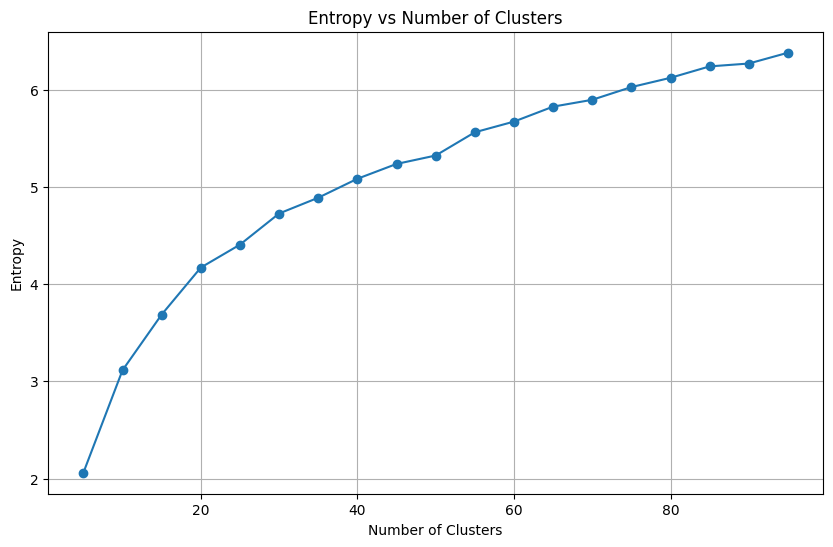

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['n_clusters'], results_df['entropy'], marker='o')
plt.title('Entropy vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Entropy')
plt.grid()
plt.show()

In [11]:
clusterer = KMeans(n_clusters=20, n_init=10)
        
train_labels = clusterer.fit_predict(train_X)

In [12]:
# get silhouette score and davies bouldin score
from sklearn.metrics import silhouette_score, davies_bouldin_score
silhouette = silhouette_score(train_X, train_labels)
davies_bouldin = davies_bouldin_score(train_X, train_labels)
print(f"Silhouette Score: {silhouette}")
print(f"Davies-Bouldin Score: {davies_bouldin}")

Silhouette Score: 0.1904608358815396
Davies-Bouldin Score: 1.6660569625460504


In [10]:

tsne = TSNE(n_components=3, random_state=42, perplexity=30, n_iter=1000)
tsne_results = tsne.fit_transform(train_X)

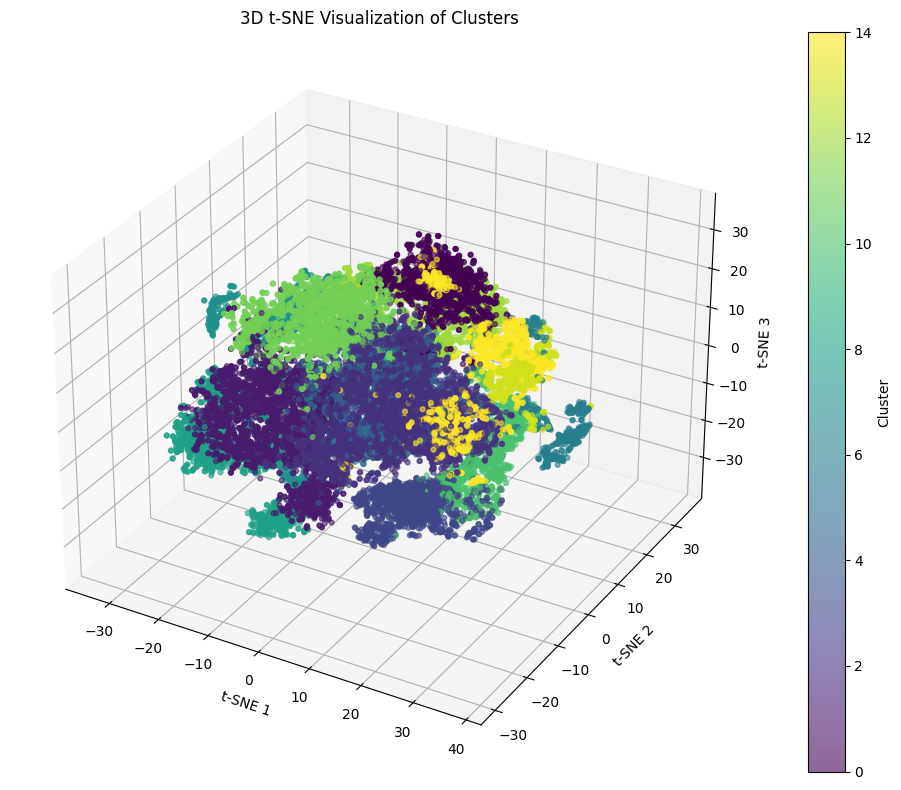

In [11]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    tsne_results[:, 0], tsne_results[:, 1], tsne_results[:, 2],
    c=train_labels, cmap='viridis', s=12, alpha=0.6
)

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_zlabel('t-SNE 3')
ax.set_title('3D t-SNE Visualization of Clusters')
fig.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

In [12]:
# Add final_result back to the dataframe
data_with_clusters = data.copy()
data_with_clusters['cluster'] = train_labels

# Group by cluster and get final_result statistics
final_result_by_cluster = data_with_clusters.groupby('cluster')['final_result']



In [13]:
data_with_clusters.groupby('cluster').count()['gender']


cluster
0     1499
1     2885
2     2864
3     1611
4     2548
5     1398
6      562
7     2025
8     1727
9     1061
10    1250
11    1998
12    1556
13     417
14    1059
Name: gender, dtype: int64

In [14]:
fail_or_drop_out_clusers = data_with_clusters.groupby('cluster')['final_result'].value_counts(
    normalize=True).groupby(level=0).apply(
        lambda x: x[x.index.get_level_values(1).isin([-0.5, 0])].sum()).where(
        lambda x: x > 0.666).dropna()

In [15]:
fail_or_drop_out_clusers

cluster
0     0.751835
2     0.760475
6     0.985765
7     0.979753
10    0.801600
13    0.976019
14    0.857413
Name: proportion, dtype: float64

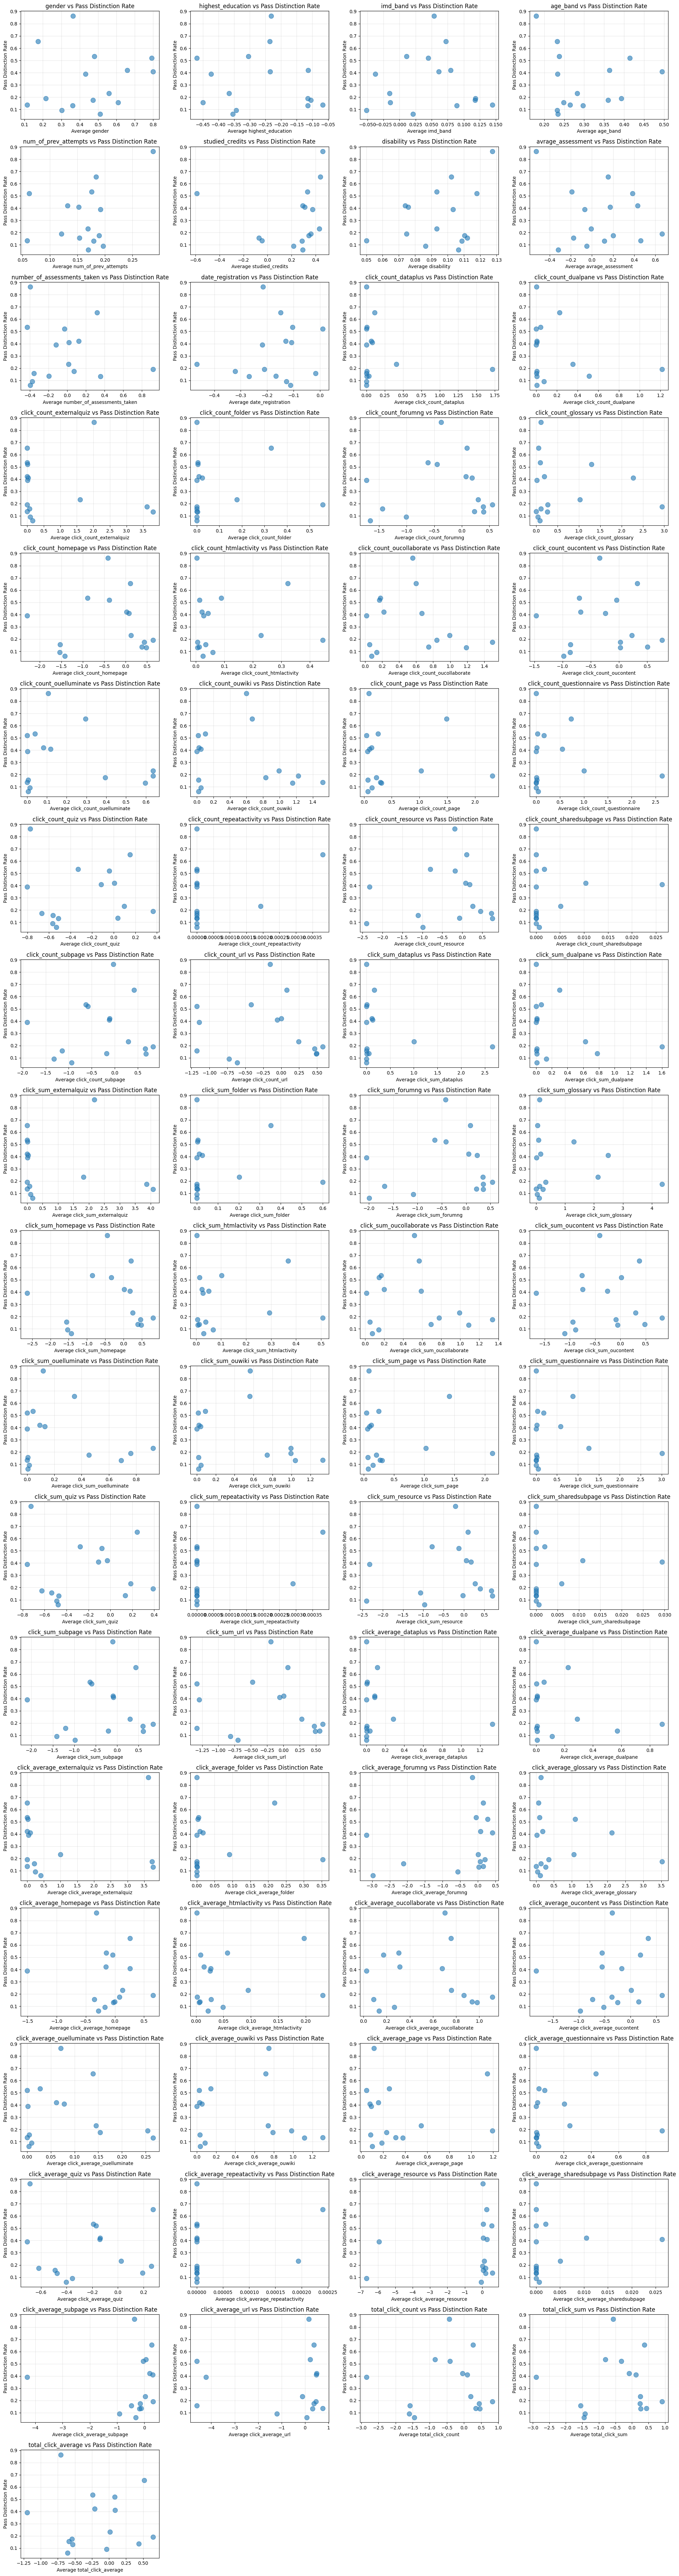

In [16]:
# Calculate pass/fail distinction rate for each cluster
cluster_stats = data_with_clusters.groupby('cluster')['final_result'].apply(
    lambda x: (x < 0).sum() / len(x)
).sort_values(ascending=False)

# Calculate cluster statistics for each column
cluster_stats_by_column = {}
for col in data.columns:
    if col != 'cluster' and col != 'final_result':
        cluster_stats_by_column[col] = data_with_clusters.groupby('cluster')[col].mean()

# Create scatter plots for each column
col_list = [col for col in data.columns if col != 'cluster' and col != 'final_result']
num_cols = len(col_list)
num_rows = (num_cols + 3) // 4  # 4 plots per row

fig, axes = plt.subplots(num_rows, 4, figsize=(20, num_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(col_list):
    axes[idx].scatter(cluster_stats_by_column[col], cluster_stats.values, s=100, alpha=0.6)
    axes[idx].set_xlabel(f'Average {col}')
    axes[idx].set_ylabel('Pass Distinction Rate')
    axes[idx].set_title(f'{col} vs Pass Distinction Rate')
    axes[idx].grid(alpha=0.3)

# Hide unused subplots
for idx in range(len(col_list), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


Correlation of features with final_result by cluster:
           gender  highest_education  imd_band  age_band  \
cluster                                                    
4        0.111509           0.122761  0.066155 -0.012224   
2        0.208361           0.096091  0.051714 -0.013487   
5        0.130309           0.159955  0.098216  0.098752   
1        0.053144           0.174162  0.072813 -0.027641   
11       0.030249           0.105958  0.044549  0.008804   
3        0.180322           0.059122 -0.004439  0.074557   
6        0.124694          -0.042425 -0.067329  0.090308   
10       0.186279          -0.026395  0.047570 -0.033555   
13       0.095505          -0.012794 -0.000599  0.087869   
7       -0.043814          -0.008429  0.027390  0.066661   
14       0.066940           0.049691  0.057910 -0.050942   
0       -0.100950           0.115058  0.075422 -0.082474   
12      -0.078086           0.138164  0.083307 -0.024067   
9       -0.110881           0.139227  0.123201

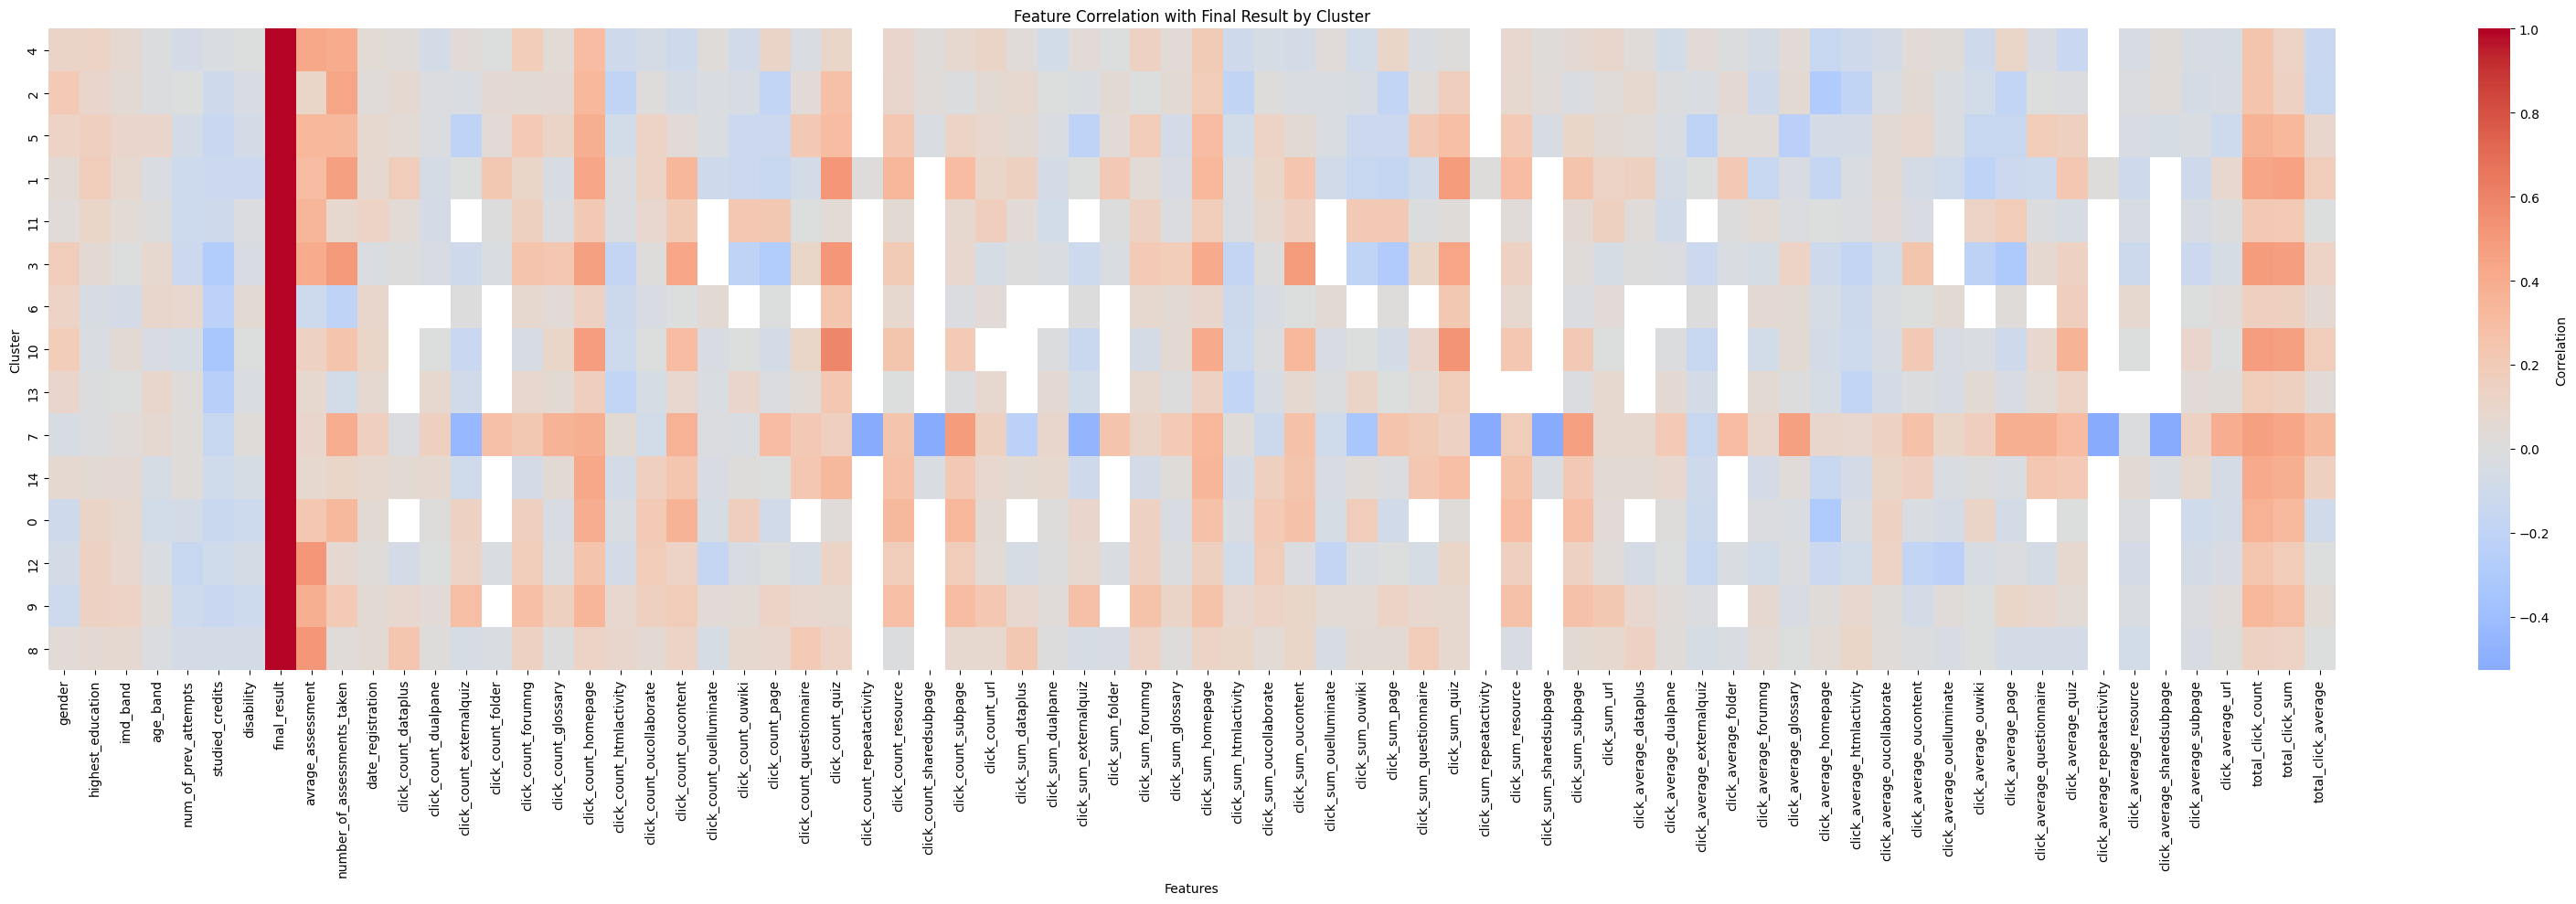

In [17]:
import seaborn as sns
# Calculate correlation for each metric with final_result by cluster
correlation_by_cluster = {}

for cluster in data_with_clusters['cluster'].unique():
    cluster_data = data_with_clusters[data_with_clusters['cluster'] == cluster]
    correlations = cluster_data.drop(columns=['cluster']).corrwith(cluster_data['final_result'])
    correlation_by_cluster[cluster] = correlations

# Convert to DataFrame for better visualization
correlation_df = pd.DataFrame(correlation_by_cluster).T
correlation_df.index.name = 'cluster'

# Display top correlated features for each cluster
print("Correlation of features with final_result by cluster:")
print(correlation_df)

# Visualize correlations as a heatmap
plt.figure(figsize=(32, 10))
sns.heatmap(correlation_df, cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation with Final Result by Cluster')
plt.xlabel('Features')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

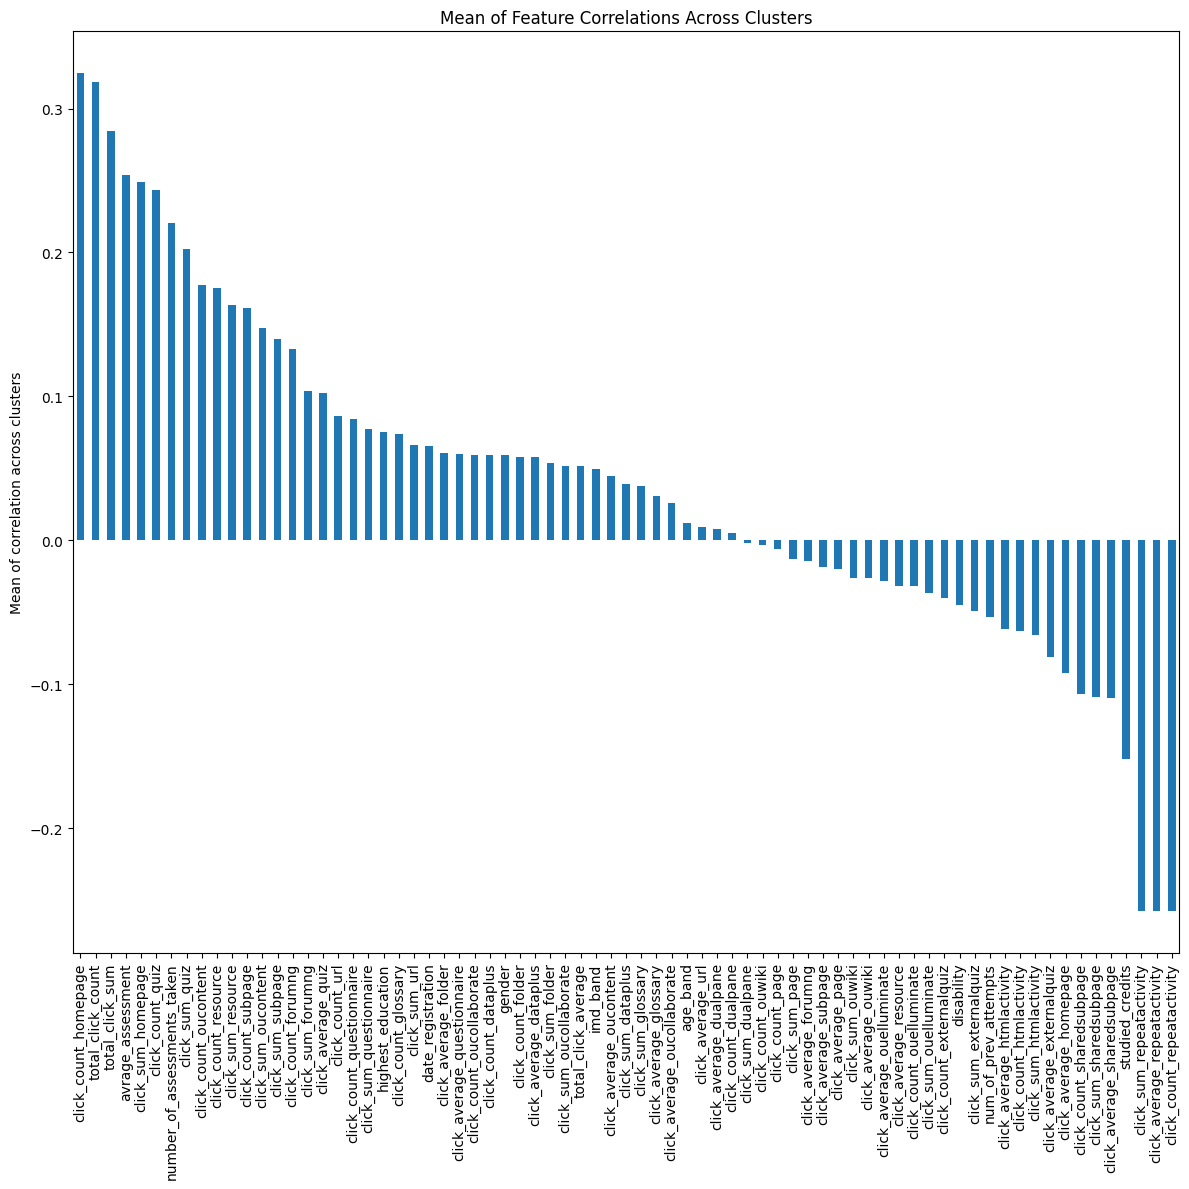

In [18]:
# Sum correlations across clusters and display vertically
mean_corr = correlation_df.mean(axis=0).drop('final_result').sort_values(ascending=False)

plt.figure(figsize=(12, 12))
mean_corr.plot(kind='bar')
plt.ylabel('Mean of correlation across clusters')
plt.title('Mean of Feature Correlations Across Clusters')
plt.tight_layout()
plt.show()

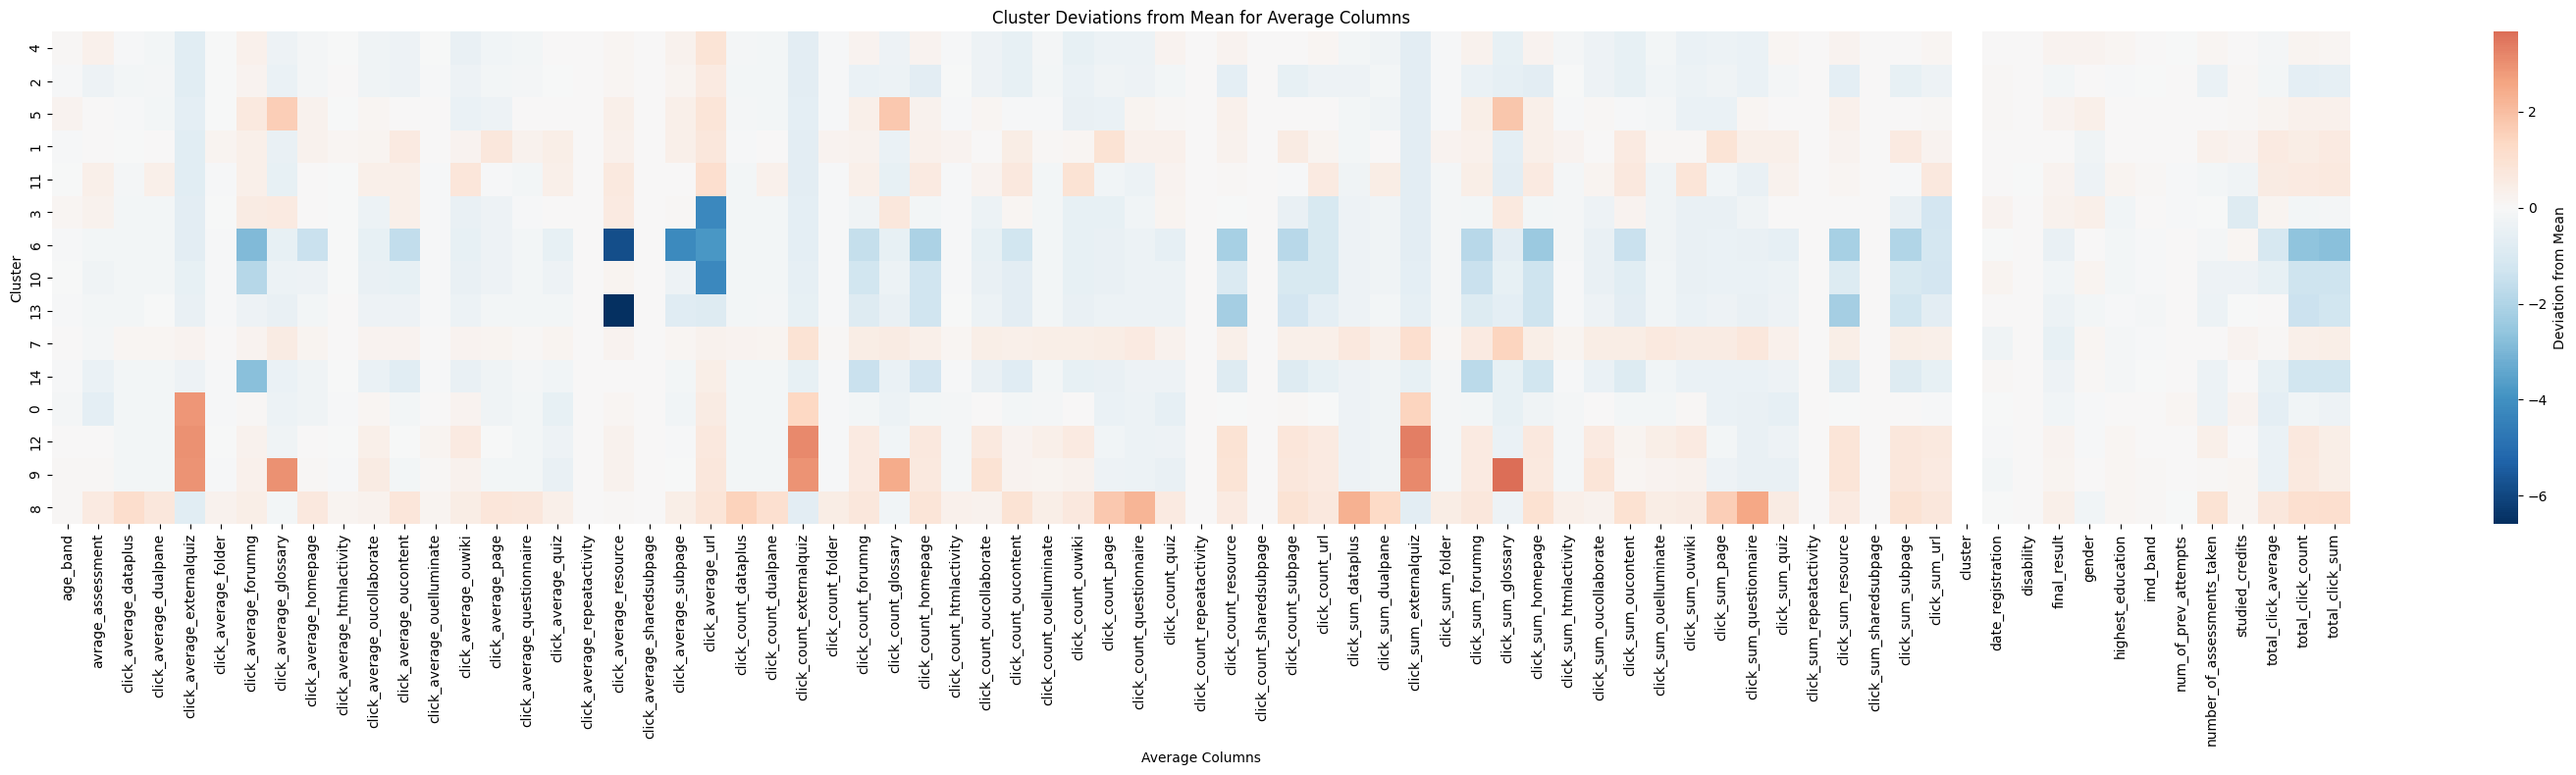

In [20]:
# Calculate deviation from mean for each cluster
cluster_deviations = {}
for cluster in data_with_clusters['cluster'].unique():
    cluster_data = data_with_clusters[data_with_clusters['cluster'] == cluster]
    deviations = cluster_data.mean() - data.mean()
    cluster_deviations[cluster] = deviations

# Create DataFrame from deviations
deviation_df = pd.DataFrame(cluster_deviations).T

# Plot heatmap
plt.figure(figsize=(30, 8))
sns.heatmap(deviation_df, cmap='RdBu_r', center=0, cbar_kws={'label': 'Deviation from Mean'}, annot=False)
plt.title('Cluster Deviations from Mean for Average Columns')
plt.xlabel('Average Columns')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [25]:
# Sort clusters by mean final_result
cluster_final_result = data_with_clusters.groupby('cluster')['final_result'].apply(
    lambda x: (x < 0).sum() / len(x)
).sort_values(ascending=False)
print(cluster_final_result)

cluster
1    0.651399
9    0.609921
8    0.487633
7    0.424466
0    0.259933
3    0.240774
5    0.195586
4    0.186851
2    0.106977
6    0.075520
Name: final_result, dtype: float64


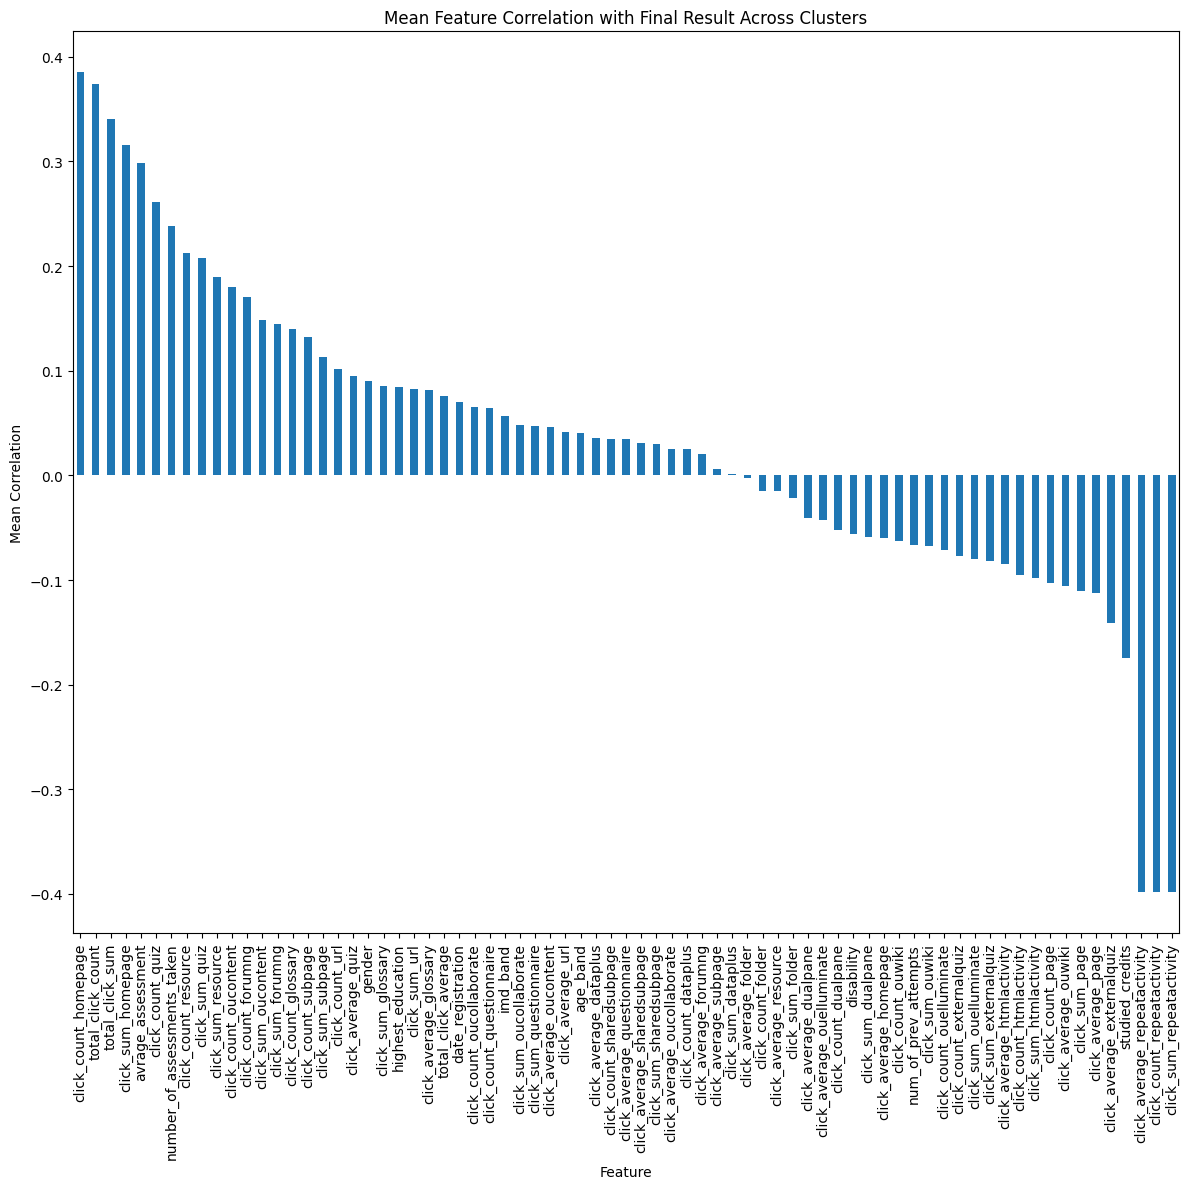

In [32]:
# Calculate and plot the mean correlation of each feature with final_result across clusters
correlations_list = []
for cluster in sorted(data_with_clusters['cluster'].unique()):
    cluster_data = data_with_clusters[data_with_clusters['cluster'] == cluster]
    corr = cluster_data.drop(columns=['cluster']).corrwith(cluster_data['final_result'])
    correlations_list.append(corr)

correlations_df = pd.DataFrame(correlations_list, index=sorted(data_with_clusters['cluster'].unique()))

# Drop 'final_result' column if present
if 'final_result' in correlations_df.columns:
    correlations_df = correlations_df.drop(columns=['final_result'])

mean_correlation = correlations_df.mean().sort_values(ascending=False)

plt.figure(figsize=(12, 12))
mean_correlation.plot(kind='bar')
plt.title('Mean Feature Correlation with Final Result Across Clusters')
plt.ylabel('Mean Correlation')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()


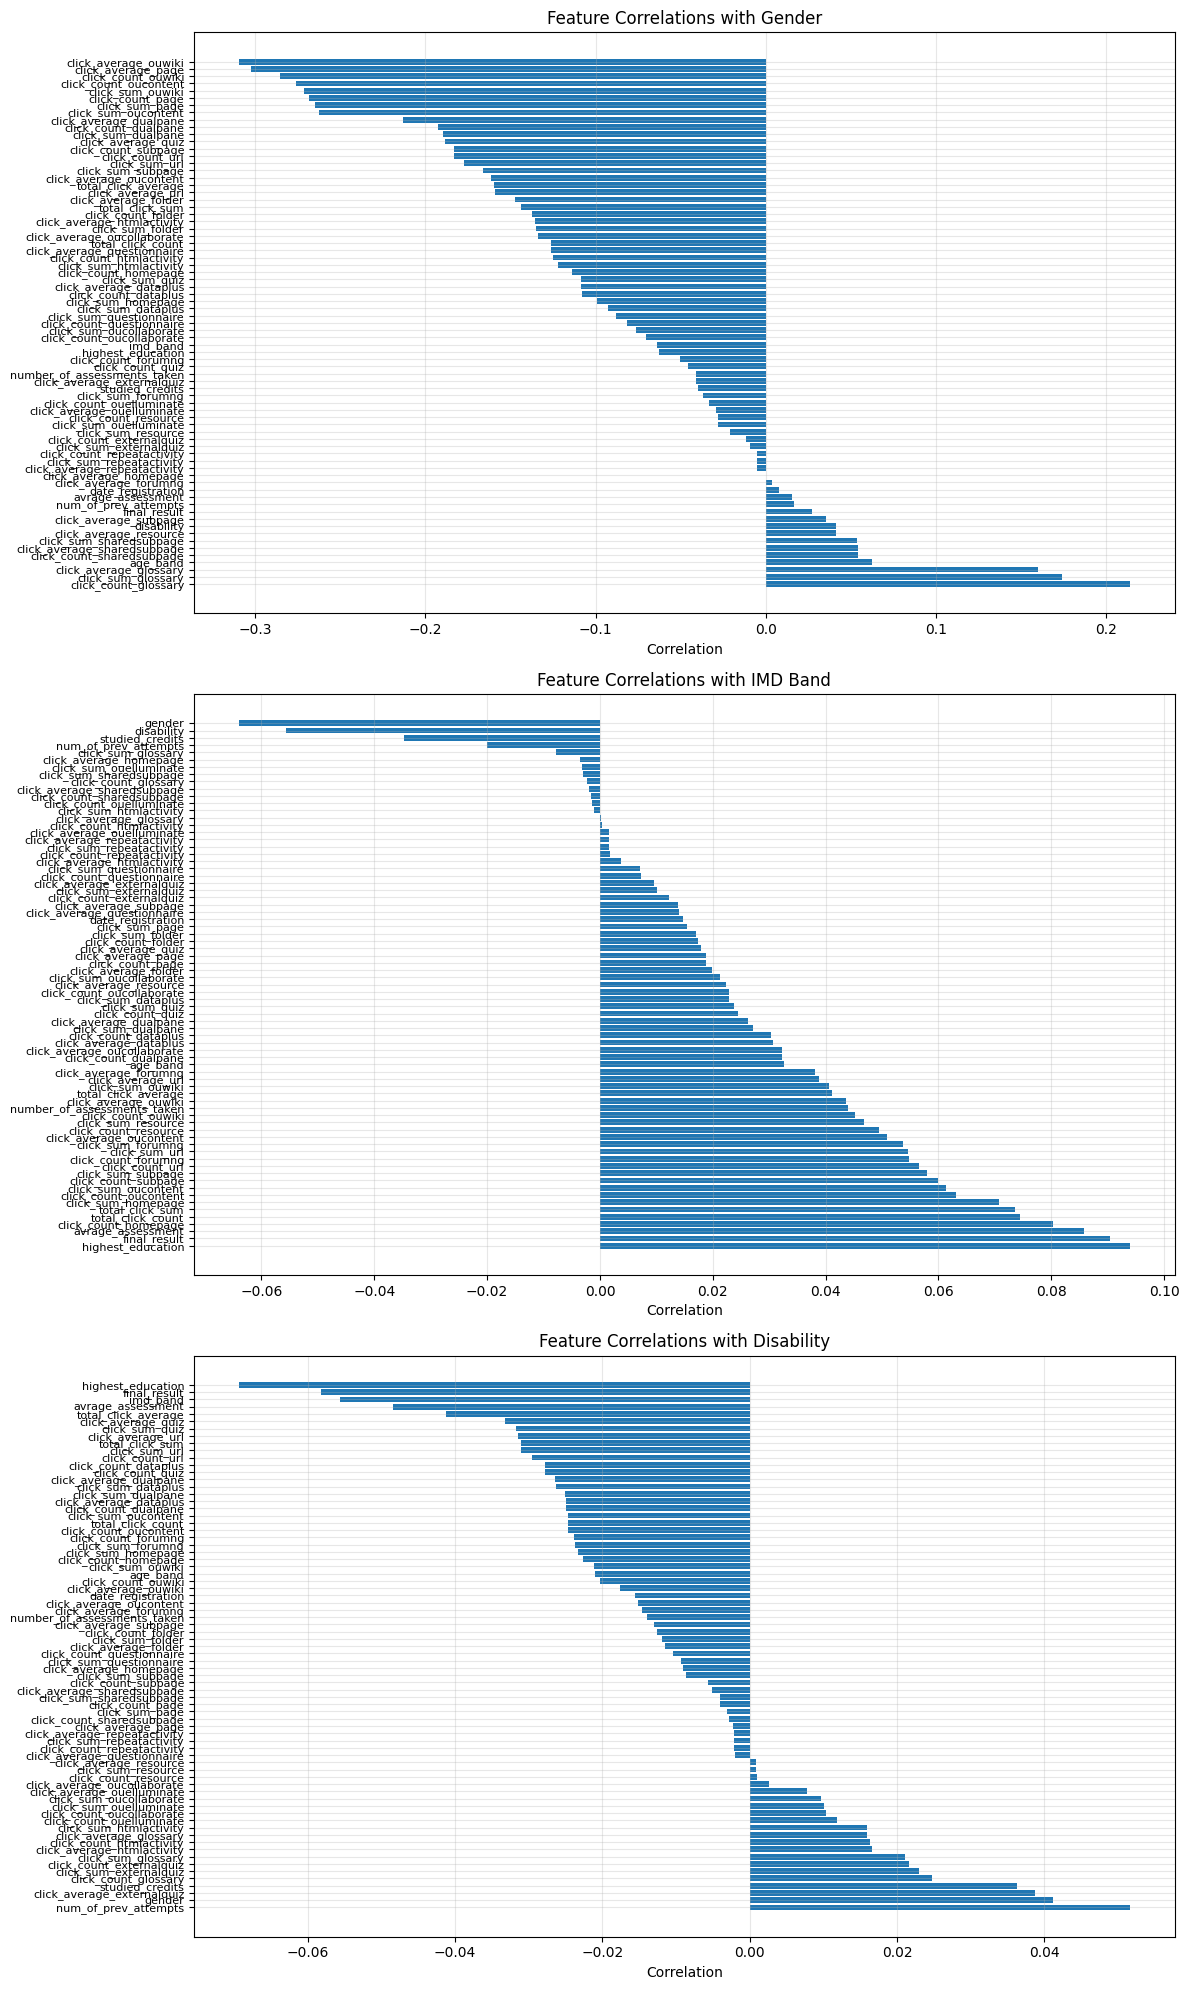

In [35]:
# Create three plots showing correlations with gender, imd_band, and disability for all students
fig, axes = plt.subplots(3, 1, figsize=(12, 20))

# Plot 1: Gender correlations
gender_corr = data_with_clusters.drop(columns=['cluster']).corrwith(data_with_clusters['gender']).drop('gender').sort_values(ascending=False)
axes[0].barh(range(len(gender_corr)), gender_corr.values)
axes[0].set_yticks(range(len(gender_corr)))
axes[0].set_yticklabels(gender_corr.index, fontsize=8)
axes[0].set_xlabel('Correlation')
axes[0].set_title('Feature Correlations with Gender')
axes[0].grid(alpha=0.3)

# Plot 2: IMD Band correlations
imd_corr = data_with_clusters.drop(columns=['cluster']).corrwith(data_with_clusters['imd_band']).drop('imd_band').sort_values(ascending=False)
axes[1].barh(range(len(imd_corr)), imd_corr.values)
axes[1].set_yticks(range(len(imd_corr)))
axes[1].set_yticklabels(imd_corr.index, fontsize=8)
axes[1].set_xlabel('Correlation')
axes[1].set_title('Feature Correlations with IMD Band')
axes[1].grid(alpha=0.3)

# Plot 3: Disability correlations
disability_corr = data_with_clusters.drop(columns=['cluster']).corrwith(data_with_clusters['disability']).drop('disability').sort_values(ascending=False)
axes[2].barh(range(len(disability_corr)), disability_corr.values)
axes[2].set_yticks(range(len(disability_corr)))
axes[2].set_yticklabels(disability_corr.index, fontsize=8)
axes[2].set_xlabel('Correlation')
axes[2].set_title('Feature Correlations with Disability')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()